C:\Users\dubes\AppData\Local\Temp\ipykernel_4168\95364923.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=nhts_data, y='vehicle_type', palette='inferno')


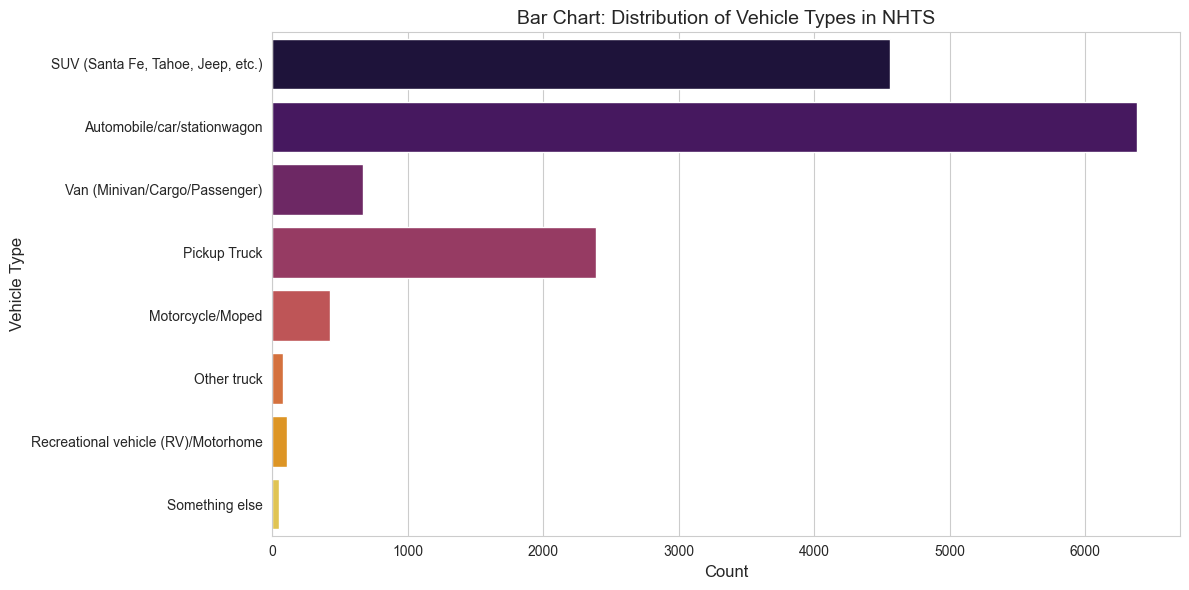

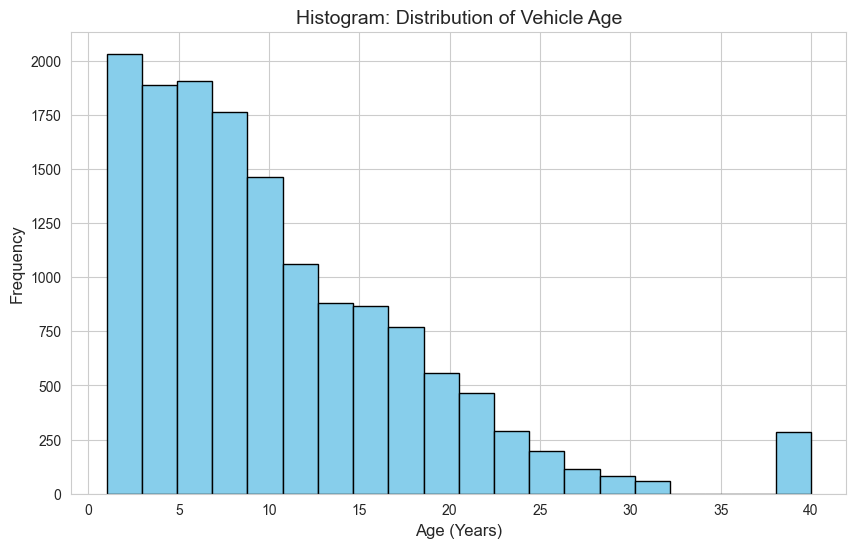

<Figure size 1200x600 with 0 Axes>

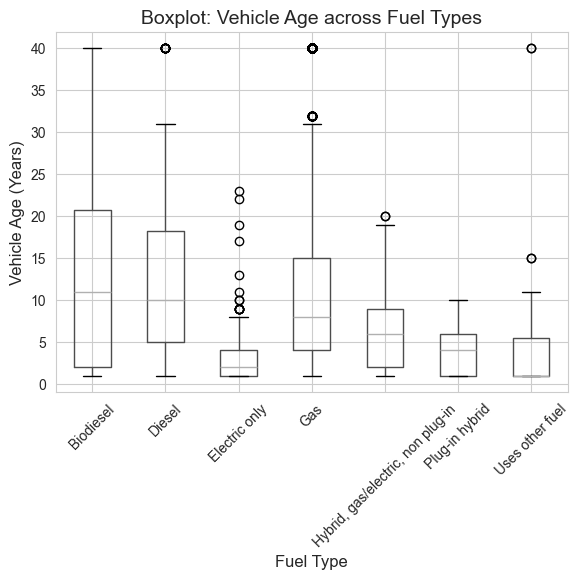

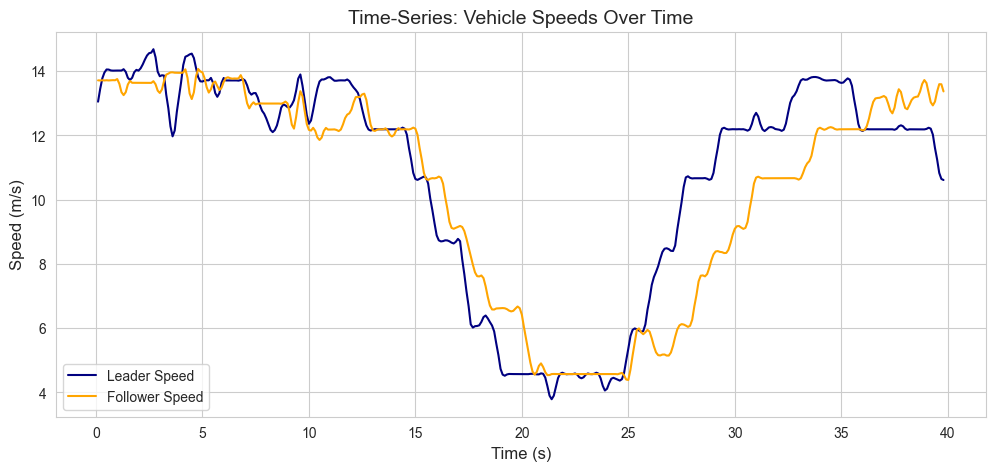

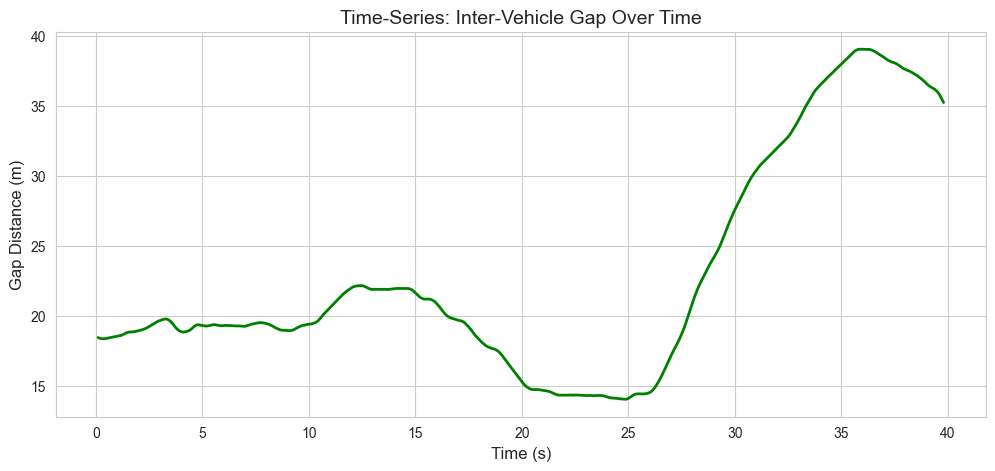

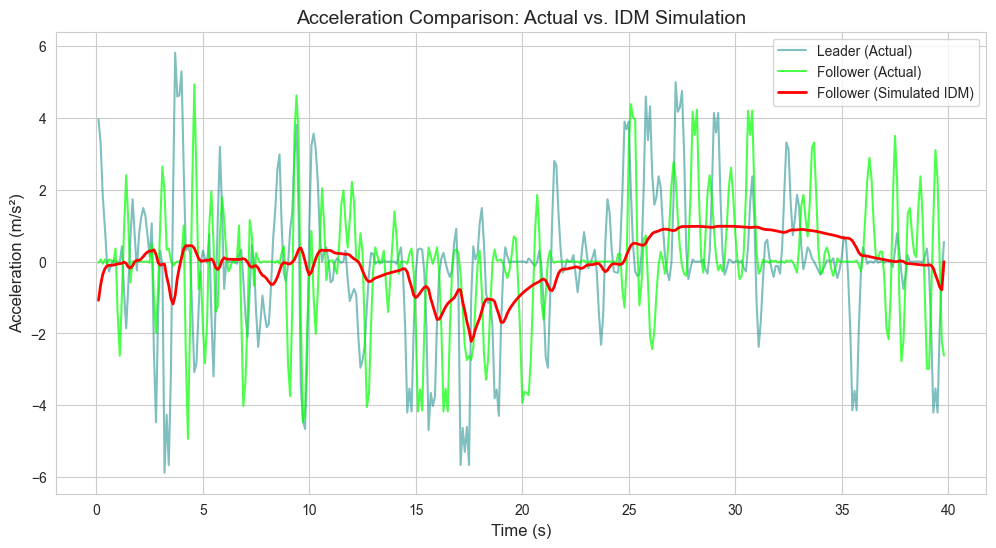

In [2]:
#Couldn't add cells with just words and not code so I used hashtags to seperate code
#Import python libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Set style
sns.set_style('whitegrid')
sns.set_palette('deep')
#Import data
nhts_data = pd.read_csv('NHTS(in).csv')
ngsim_data = pd.read_csv('NGSIM(in).csv')

#1. Bar Chart:
plt.figure(figsize=(12, 6))
sns.countplot(data=nhts_data, y='vehicle_type', palette='inferno')
plt.xlabel('Count', fontsize=12)
plt.ylabel('Vehicle Type', fontsize=12)
plt.title('Bar Chart: Distribution of Vehicle Types in NHTS', fontsize=14)
plt.tight_layout()
plt.show()

#2. Histogram: Distribution of a specific variable (Vehicle Age)
plt.figure(figsize=(10, 6))
plt.hist(nhts_data['vehicle_age'], bins=20, color='skyblue', edgecolor='black')
plt.title('Histogram: Distribution of Vehicle Age', fontsize=14)
plt.xlabel('Age (Years)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

#3. Boxplot: Distribution by category (Age by Fuel Type)
plt.figure(figsize=(12, 6))
nhts_data.boxplot(column='vehicle_age', by='fuel_type')
plt.xticks(rotation=45)
plt.xlabel('Fuel Type', fontsize=12)
plt.ylabel('Vehicle Age (Years)', fontsize=12)
plt.title('Boxplot: Vehicle Age across Fuel Types', fontsize=14)
plt.suptitle('') 
plt.show()

#Selecting trajectory
trajectory_number = 2 
data_subset = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number].copy()
time_data = data_subset['Time'].values

#Plot 1: Speed vs Time (Driving Behavior)
plt.figure(figsize=(12, 5))
plt.plot(time_data, data_subset['leader_speed(m/s)'], color='navy', label='Leader Speed')
plt.plot(time_data, data_subset['follower_speed(m/s)'], color='orange', label='Follower Speed')
plt.title('Time-Series: Vehicle Speeds Over Time', fontsize=14)
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Speed (m/s)', fontsize=12)
plt.legend()
plt.show()

#Plot 2: Gap Distance vs Time (Safety Behavior)
#Calculating Gap: Leader Position - Follower Position
gap_dist = data_subset['leader_position(m)'].values - data_subset['follower_position(m)'].values
plt.figure(figsize=(12, 5))
plt.plot(time_data, gap_dist, color='green', linewidth=2)
plt.title('Time-Series: Inter-Vehicle Gap Over Time', fontsize=14)
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Gap Distance (m)', fontsize=12)
plt.show()


#Define IDM Function
def idm_acceleration(v, s, delta_v, v0, s0, T, a, b, delta):
    s_star = s0 + v * T + (v * delta_v) / (2 * np.sqrt(a * b))
    s_star = max(s_star, s0)
    acceleration = a * (1 - (v/v0)**delta - (s_star/s)**2)
    return acceleration

#2.Simulation Setup
v0 = 30.0    # Desired velocity
s0 = 2.0     # Minimum spacing
T = 1.5      # Time headway
a_param = 1.0 # Maximum acceleration
b = 1.5      # Comfort deceleration
delta = 4.0  # Exponent
dt = 0.1     # Time step

n_steps = len(time_data)
sim_position = np.zeros(n_steps)
sim_speed = np.zeros(n_steps)
sim_acc = np.zeros(n_steps)

#Initial states from NGSIM data
sim_position[0] = data_subset['follower_position(m)'].values[0]
sim_speed[0] = data_subset['follower_speed(m/s)'].values[0]
leader_pos = data_subset['leader_position(m)'].values
leader_spd = data_subset['leader_speed(m/s)'].values

#Simulation 
for i in range(n_steps - 1):
    #Current Gap and Speed Diff
    current_s = max(leader_pos[i] - sim_position[i], 0.1)
    current_dv = sim_speed[i] - leader_spd[i]
    #Calculate Acceleration
    acc = idm_acceleration(sim_speed[i], current_s, current_dv, v0, s0, T, a_param, b, delta)
    sim_acc[i] = acc 
    #Update for next step
    sim_speed[i+1] = max(sim_speed[i] + acc * dt, 0)
    sim_position[i+1] = sim_position[i] + sim_speed[i] * dt

#4.Final Comparison Plot: Acceleration
plt.figure(figsize=(12, 6))
plt.plot(time_data, data_subset['leader_acc(m/s^2)'], label='Leader (Actual)', color='teal', alpha=0.5)
plt.plot(time_data, data_subset['follower_acc(m/s^2)'], label='Follower (Actual)', color='lime', alpha=0.7)
plt.plot(time_data, sim_acc, label='Follower (Simulated IDM)', color='red', linewidth=2)
plt.title('Acceleration Comparison: Actual vs. IDM Simulation', fontsize=14)
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Acceleration (m/s²)', fontsize=12)
plt.legend()
plt.show()